# Inference Strategy Comparison (7BNY)

Compare inference-time strategies for improving contact prediction accuracy:
1. Baseline: equal-weight rollout consensus
2. Perplexity-weighted consensus
3. Best-of-N selection
4. Per-contact confidence filtering
5. Threshold & rollout count sweep
6. Correction-prompted iterative refinement

In [1]:
# Config
CHECKPOINT_PATH = "../../outputs/exp5.ethereal-galaxy-3/checkpoint-125500"
PDB_ID = "7BNY"
CONTACT_DISTANCE_CUTOFF = 4.0
BIN_EDGES = [4.0, 12.0]
MAX_NEW_TOKENS = 3440
N_ROLLOUTS = 50
SEP_THRESHOLD = 6
DEVICE = "cuda"

In [2]:
# Setup: PDB structure, GT contacts, model
import tempfile, time, math
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from collections import Counter
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids
from scipy.spatial import KDTree
from transformers import LlamaForCausalLM
from experiments.exp5_contact_prediction.src.data import AMINO_ACIDS, VALID_ATOMS, PLDDT_TOKENS
from experiments.exp5_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

NONSTANDARD_AA_MAP = {
    "MSE": "MET", "CSE": "CYS", "SEC": "CYS", "HYP": "PRO",
    "TPO": "THR", "SEP": "SER", "PTR": "TYR",
}

# Parse structure
path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
cif = pdbx.CIFFile.read(path)
atoms = pdbx.get_structure(cif.block, model=1)
first_chain = atoms.chain_id[0]
chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]
res_ids = chain_atoms.res_id
unique_res = sorted(set(res_ids))
res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}
aa_set = set(AMINO_ACIDS)
sequence = [NONSTANDARD_AA_MAP.get(str(chain_atoms[chain_atoms.res_id == rid].res_name[0]),
            str(chain_atoms[chain_atoms.res_id == rid].res_name[0])) for rid in unique_res]
seq_len = len(sequence)

# GT contacts
coords = chain_atoms.coord
atom_names_arr = chain_atoms.atom_name
atom_res_ids = chain_atoms.res_id
all_known_atoms = set()
for aa in VALID_ATOMS:
    all_known_atoms.update(VALID_ATOMS[aa])

tree = KDTree(coords)
close_pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)
all_atom_contacts = []
for i, j in close_pairs:
    ri, rj = atom_res_ids[i], atom_res_ids[j]
    pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
    if pi is None or pj is None or abs(pi - pj) < 2:
        continue
    ai, aj = str(atom_names_arr[i]), str(atom_names_arr[j])
    if ai not in all_known_atoms or aj not in all_known_atoms:
        continue
    aa_i, aa_j = sequence[pi - 1], sequence[pj - 1]
    if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
        continue
    if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
        continue
    dist = float(np.linalg.norm(coords[i] - coords[j]))
    if pi > pj:
        all_atom_contacts.append((pj, pi, aj, ai, dist))
    else:
        all_atom_contacts.append((pi, pj, ai, aj, dist))

best_per_pair = {}
for c in all_atom_contacts:
    k = (c[0], c[1])
    if k not in best_per_pair or c[4] < best_per_pair[k][4]:
        best_per_pair[k] = c

gt_contacts = [(False, p1, p2, a1, a2, "bin_lt4") for p1, p2, a1, a2, _ in best_per_pair.values()]
gt_pair_set = {(c[1], c[2]) for c in gt_contacts}

# Prompt
seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
base_prompt = f"<random-3-bins> <begin_sequence> {seq_tokens} <begin_contacts>"

# Model
tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(CHECKPOINT_PATH, torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
end_token_id = tokenizer.convert_tokens_to_ids("<end>")
begin_contacts_id = tokenizer.convert_tokens_to_ids("<begin_contacts>")
correction_ids = {tokenizer.convert_tokens_to_ids("<correction>"),
                  tokenizer.convert_tokens_to_ids("<non-correction>")}
plddt_ids = {tokenizer.convert_tokens_to_ids(t) for t in PLDDT_TOKENS}

print(f"Protein {PDB_ID}: {seq_len} residues, {len(gt_pair_set)} GT contact pairs")
print(f"Model: {sum(p.numel() for p in model.parameters()):,} parameters")

/home/ubuntu/llm-protein-experiments/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|                                                                                                         | 0/147 [00:00<?, ?it/s]

Loading weights:   1%|▍                                                          | 1/147 [00:00<00:00, 4934.48it/s, Materializing param=lm_head.weight]

Loading weights:   1%|▍                                                           | 1/147 [00:00<00:00, 860.02it/s, Materializing param=lm_head.weight]

Loading weights:   1%|▋                                                 | 2/147 [00:00<00:02, 62.47it/s, Materializing param=model.embed_tokens.weight]

...

Loading weights:  99%|████████████████████████████████▊| 146/147 [00:00<00:00, 266.32it/s, Materializing param=model.layers.15.self_attn.v_proj.weight]

Loading weights: 100%|███████████████████████████████████████████████████████| 147/147 [00:00<00:00, 266.32it/s, Materializing param=model.norm.weight]

Loading weights: 100%|███████████████████████████████████████████████████████| 147/147 [00:00<00:00, 266.32it/s, Materializing param=model.norm.weight]

Loading weights: 100%|███████████████████████████████████████████████████████| 147/147 [00:00<00:00, 369.07it/s, Materializing param=model.norm.weight]

Protein 7BNY: 132 residues, 347 GT contact pairs
Model: 984,528,896 parameters


In [3]:
# Helper functions
def run_generation(prompt, do_sample=False):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS, pad_token_id=tokenizer.pad_token_id,
                      eos_token_id=end_token_id)
    if do_sample:
        gen_kwargs.update(do_sample=True, temperature=1.0, top_k=0)
    else:
        gen_kwargs.update(do_sample=False)
    t0 = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, **gen_kwargs)
    elapsed = time.time() - t0
    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid, plddt = parse_generated_contacts(gen_text.split())
    return contacts, valid, plddt, elapsed

def build_document(contacts, plddt_token=None):
    toks = []
    for is_corr, p1, p2, a1, a2, bin_tok in contacts:
        corr = "<correction>" if is_corr else "<non-correction>"
        toks.extend([corr, f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>", f"<{bin_tok}>"])
    if plddt_token:
        toks.append(f"<{plddt_token}>")
    return base_prompt + " " + " ".join(toks) + " <end_contacts> <end>"

def compute_ppl(doc_text):
    """Compute contacts-region perplexity."""
    enc = tokenizer(doc_text, return_tensors="pt", truncation=True, max_length=8192)
    input_ids = enc["input_ids"].to(DEVICE)
    with torch.no_grad():
        logits = model(input_ids=input_ids).logits
    loss = F.cross_entropy(logits[0, :-1], input_ids[0, 1:], reduction="none")
    ids = input_ids[0].tolist()
    bc_pos = next((i for i, t in enumerate(ids) if t == begin_contacts_id), 0)
    return math.exp(loss[bc_pos:].mean().item())

def compute_per_contact_logprobs(doc_text):
    """Return list of (contact_tuple, avg_logprob) for each contact."""
    enc = tokenizer(doc_text, return_tensors="pt", truncation=True, max_length=8192)
    input_ids = enc["input_ids"].to(DEVICE)
    with torch.no_grad():
        logits = model(input_ids=input_ids).logits
    log_probs = -F.cross_entropy(logits[0, :-1], input_ids[0, 1:], reduction="none")
    ids = input_ids[0].tolist()
    bc_pos = next((i for i, t in enumerate(ids) if t == begin_contacts_id), None)
    if bc_pos is None:
        return []
    results = []
    j = bc_pos + 1
    while j < len(ids):
        tid = ids[j]
        if tid in plddt_ids:
            j += 1
            continue
        if tid in correction_ids and j + 6 <= len(ids):
            lp_start = j - 1  # shifted for causal LM
            lp_end = lp_start + 6
            if lp_end <= len(log_probs):
                avg_lp = log_probs[lp_start:lp_end].mean().item()
                results.append(avg_lp)
            j += 6
        else:
            break
    return results

def contacts_to_pair_set(contacts, bin_filter="bin_lt4"):
    return {(min(c[1], c[2]), max(c[1], c[2])) for c in contacts if c[5] == bin_filter}

def contacts_to_matrix(contacts, seq_len, bin_filter="bin_lt4"):
    matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for c in contacts:
        if c[5] == bin_filter:
            p1, p2 = c[1], c[2]
            if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
                matrix[p1 - 1, p2 - 1] = 1
                matrix[p2 - 1, p1 - 1] = 1
    return matrix

def eval_pairs(pred_pairs, gt_pairs, threshold=SEP_THRESHOLD):
    """Compute precision, recall, F1 overall and by range."""
    short_gt = {p for p in gt_pairs if abs(p[0] - p[1]) < threshold}
    long_gt = {p for p in gt_pairs if abs(p[0] - p[1]) >= threshold}
    short_pred = {p for p in pred_pairs if abs(p[0] - p[1]) < threshold}
    long_pred = {p for p in pred_pairs if abs(p[0] - p[1]) >= threshold}
    def _metrics(pred, gt):
        n = len(pred)
        c = len(pred & gt)
        p = c / n if n > 0 else 0
        r = c / len(gt) if gt else 0
        f = 2*p*r/(p+r) if (p+r) > 0 else 0
        return {"prec": p, "rec": r, "f1": f, "n_pred": n, "n_correct": c, "n_gt": len(gt)}
    return {"all": _metrics(pred_pairs, gt_pairs),
            "short": _metrics(short_pred, short_gt),
            "long": _metrics(long_pred, long_gt)}

def print_eval(label, metrics):
    for scope in ["all", "short", "long"]:
        m = metrics[scope]
        print(f"  {label} [{scope:>5s}]: P={m['prec']:.1%} R={m['rec']:.1%} F1={m['f1']:.3f} "
              f"({m['n_correct']}/{m['n_pred']} correct, {m['n_gt']} GT)")

print("Helpers ready.")

Helpers ready.


In [4]:
# Generate N rollouts + greedy
print(f"Generating {N_ROLLOUTS} rollouts + greedy...")
greedy_contacts, greedy_valid, greedy_plddt, greedy_time = run_generation(base_prompt, do_sample=False)
print(f"Greedy: {len(greedy_contacts)} contacts, valid={greedy_valid}, {greedy_time:.1f}s")

all_rollouts = []  # list of (contacts, valid, plddt)
all_times = []
for r in range(N_ROLLOUTS):
    contacts, valid, plddt, elapsed = run_generation(base_prompt, do_sample=True)
    all_rollouts.append((contacts, valid, plddt))
    all_times.append(elapsed)
    if (r + 1) % 10 == 0:
        print(f"  {r+1}/{N_ROLLOUTS} done, avg {np.mean(all_times):.1f}s/rollout")

print(f"\nGenerated {N_ROLLOUTS} rollouts in {sum(all_times):.0f}s (avg {np.mean(all_times):.1f}s)")
print(f"Valid grammar: {sum(1 for c,v,p in all_rollouts if v)}/{N_ROLLOUTS}")

Generating 50 rollouts + greedy...


Greedy: 41 contacts, valid=True, 4.3s


  10/50 done, avg 36.6s/rollout


  20/50 done, avg 36.4s/rollout


  30/50 done, avg 36.8s/rollout


  40/50 done, avg 36.9s/rollout


  50/50 done, avg 37.6s/rollout

Generated 50 rollouts in 1879s (avg 37.6s)
Valid grammar: 45/50


In [5]:
# Score each rollout by perplexity
print("Computing per-rollout perplexity...")
rollout_ppls = []
for r, (contacts, valid, plddt) in enumerate(all_rollouts):
    doc = build_document(contacts, plddt)
    ppl = compute_ppl(doc)
    rollout_ppls.append(ppl)
    if (r + 1) % 10 == 0:
        print(f"  {r+1}/{N_ROLLOUTS} scored")

print(f"PPL: mean={np.mean(rollout_ppls):.2f}, min={np.min(rollout_ppls):.2f}, max={np.max(rollout_ppls):.2f}")

Computing per-rollout perplexity...


  10/50 scored


  20/50 scored


  30/50 scored


  40/50 scored


  50/50 scored
PPL: mean=4.07, min=3.57, max=4.92


In [6]:
# Strategy 0: Baseline - equal-weight consensus (N=10 and N=50)
%matplotlib inline
import matplotlib.pyplot as plt

def consensus_pairs(rollouts, n_rollouts, threshold=0.5):
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for contacts, valid, plddt in rollouts[:n_rollouts]:
        freq += contacts_to_matrix(contacts, seq_len)
    freq /= n_rollouts
    pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > threshold:
                pairs.add((i + 1, j + 1))
    return pairs, freq

print("=== Baseline: Equal-Weight Consensus ===")
for n in [10, 20, 50]:
    pairs, _ = consensus_pairs(all_rollouts, n)
    m = eval_pairs(pairs, gt_pair_set)
    print_eval(f"N={n:2d}, t=0.5", m)
    print()

=== Baseline: Equal-Weight Consensus ===
  N=10, t=0.5 [  all]: P=66.9% R=22.8% F1=0.340 (79/118 correct, 347 GT)
  N=10, t=0.5 [short]: P=66.4% R=52.7% F1=0.588 (77/116 correct, 146 GT)
  N=10, t=0.5 [ long]: P=100.0% R=1.0% F1=0.020 (2/2 correct, 201 GT)

  N=20, t=0.5 [  all]: P=64.1% R=26.2% F1=0.372 (91/142 correct, 347 GT)
  N=20, t=0.5 [short]: P=64.1% R=62.3% F1=0.632 (91/142 correct, 146 GT)
  N=20, t=0.5 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  N=50, t=0.5 [  all]: P=63.7% R=24.8% F1=0.357 (86/135 correct, 347 GT)
  N=50, t=0.5 [short]: P=63.7% R=58.9% F1=0.612 (86/135 correct, 146 GT)
  N=50, t=0.5 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)



In [7]:
# Strategy 1: Perplexity-weighted consensus
print("=== Strategy 1: Perplexity-Weighted Consensus ===")

def weighted_consensus_pairs(rollouts, ppls, n_rollouts, threshold=0.5, sharpness=1.0):
    weights = np.array([1.0 / (ppl ** sharpness) for ppl in ppls[:n_rollouts]])
    weights /= weights.sum()
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for w, (contacts, valid, plddt) in zip(weights, rollouts[:n_rollouts]):
        freq += w * contacts_to_matrix(contacts, seq_len)
    pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > threshold:
                pairs.add((i + 1, j + 1))
    return pairs, freq

for sharp in [0.5, 1.0, 2.0]:
    pairs, _ = weighted_consensus_pairs(all_rollouts, rollout_ppls, N_ROLLOUTS, sharpness=sharp)
    m = eval_pairs(pairs, gt_pair_set)
    print_eval(f"sharp={sharp}", m)
    print()

=== Strategy 1: Perplexity-Weighted Consensus ===
  sharp=0.5 [  all]: P=64.3% R=26.5% F1=0.376 (92/143 correct, 347 GT)
  sharp=0.5 [short]: P=64.3% R=63.0% F1=0.637 (92/143 correct, 146 GT)
  sharp=0.5 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  sharp=1.0 [  all]: P=64.3% R=26.5% F1=0.376 (92/143 correct, 347 GT)
  sharp=1.0 [short]: P=64.3% R=63.0% F1=0.637 (92/143 correct, 146 GT)
  sharp=1.0 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  sharp=2.0 [  all]: P=65.1% R=27.4% F1=0.385 (95/146 correct, 347 GT)
  sharp=2.0 [short]: P=65.1% R=65.1% F1=0.651 (95/146 correct, 146 GT)
  sharp=2.0 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)



In [8]:
# Strategy 2: Best-of-N selection
print("=== Strategy 2: Best-of-N (lowest PPL) ===")

sorted_indices = np.argsort(rollout_ppls)

# Single best
best_idx = sorted_indices[0]
best_contacts = all_rollouts[best_idx][0]
best_pairs = contacts_to_pair_set(best_contacts)
m = eval_pairs(best_pairs, gt_pair_set)
print_eval(f"Best-1 (R{best_idx}, ppl={rollout_ppls[best_idx]:.2f})", m)
print()

# Top-K consensus
for k in [3, 5, 10]:
    top_k = sorted_indices[:k]
    top_rollouts = [(all_rollouts[i][0], all_rollouts[i][1], all_rollouts[i][2]) for i in top_k]
    top_ppls = [rollout_ppls[i] for i in top_k]
    # Weighted consensus among top-K
    pairs, _ = weighted_consensus_pairs(top_rollouts, top_ppls, k, threshold=0.5, sharpness=1.0)
    m = eval_pairs(pairs, gt_pair_set)
    avg_ppl = np.mean(top_ppls)
    print_eval(f"Top-{k} consensus (avg_ppl={avg_ppl:.2f})", m)
    print()

=== Strategy 2: Best-of-N (lowest PPL) ===
  Best-1 (R18, ppl=3.57) [  all]: P=35.4% R=30.3% F1=0.326 (105/297 correct, 347 GT)
  Best-1 (R18, ppl=3.57) [short]: P=40.8% R=69.9% F1=0.515 (102/250 correct, 146 GT)
  Best-1 (R18, ppl=3.57) [ long]: P=6.4% R=1.5% F1=0.024 (3/47 correct, 201 GT)

  Top-3 consensus (avg_ppl=3.59) [  all]: P=45.9% R=27.7% F1=0.345 (96/209 correct, 347 GT)
  Top-3 consensus (avg_ppl=3.59) [short]: P=46.8% R=65.1% F1=0.544 (95/203 correct, 146 GT)
  Top-3 consensus (avg_ppl=3.59) [ long]: P=16.7% R=0.5% F1=0.010 (1/6 correct, 201 GT)

  Top-5 consensus (avg_ppl=3.63) [  all]: P=60.2% R=23.1% F1=0.333 (80/133 correct, 347 GT)
  Top-5 consensus (avg_ppl=3.63) [short]: P=60.8% R=54.1% F1=0.572 (79/130 correct, 146 GT)
  Top-5 consensus (avg_ppl=3.63) [ long]: P=33.3% R=0.5% F1=0.010 (1/3 correct, 201 GT)

  Top-10 consensus (avg_ppl=3.72) [  all]: P=59.7% R=26.5% F1=0.367 (92/154 correct, 347 GT)
  Top-10 consensus (avg_ppl=3.72) [short]: P=59.5% R=62.3% F1=0.609

In [9]:
# Strategy 3: Per-contact confidence filtering
print("=== Strategy 3: Per-Contact Confidence Filtering ===")
print("Computing per-contact log-probs for all rollouts...")

rollout_contact_logprobs = []  # list of list of (contact, avg_logprob)
for r, (contacts, valid, plddt) in enumerate(all_rollouts):
    doc = build_document(contacts, plddt)
    logprobs = compute_per_contact_logprobs(doc)
    # Pair contacts with logprobs (may be fewer if doc was truncated)
    paired = list(zip(contacts[:len(logprobs)], logprobs))
    rollout_contact_logprobs.append(paired)
    if (r + 1) % 10 == 0:
        print(f"  {r+1}/{N_ROLLOUTS} scored")

# Try different log-prob thresholds
all_lps = [lp for rollout in rollout_contact_logprobs for _, lp in rollout]
print(f"Log-prob range: {np.min(all_lps):.2f} to {np.max(all_lps):.2f}, median={np.median(all_lps):.2f}")

for lp_threshold in [None, -2.0, -1.5, -1.0, -0.5]:
    freq = np.zeros((seq_len, seq_len), dtype=np.float32)
    for paired in rollout_contact_logprobs:
        for contact, lp in paired:
            if contact[5] != "bin_lt4":
                continue
            if lp_threshold is not None and lp < lp_threshold:
                continue
            p1, p2 = contact[1], contact[2]
            if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
                freq[p1 - 1, p2 - 1] += 1
                freq[p2 - 1, p1 - 1] += 1
    freq /= N_ROLLOUTS
    pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq[i, j] > 0.5:
                pairs.add((i + 1, j + 1))
    label = f"lp>={lp_threshold}" if lp_threshold is not None else "no filter"
    m = eval_pairs(pairs, gt_pair_set)
    print_eval(label, m)
    print()

=== Strategy 3: Per-Contact Confidence Filtering ===
Computing per-contact log-probs for all rollouts...


  10/50 scored


  20/50 scored


  30/50 scored


  40/50 scored


  50/50 scored
Log-prob range: -4.31 to -0.03, median=-1.27
  no filter [  all]: P=64.0% R=25.1% F1=0.360 (87/136 correct, 347 GT)
  no filter [short]: P=64.0% R=59.6% F1=0.617 (87/136 correct, 146 GT)
  no filter [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  lp>=-2.0 [  all]: P=63.7% R=24.8% F1=0.357 (86/135 correct, 347 GT)
  lp>=-2.0 [short]: P=63.7% R=58.9% F1=0.612 (86/135 correct, 146 GT)
  lp>=-2.0 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  lp>=-1.5 [  all]: P=64.0% R=23.1% F1=0.339 (80/125 correct, 347 GT)
  lp>=-1.5 [short]: P=64.0% R=54.8% F1=0.590 (80/125 correct, 146 GT)
  lp>=-1.5 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  lp>=-1.0 [  all]: P=85.7% R=5.2% F1=0.098 (18/21 correct, 347 GT)
  lp>=-1.0 [short]: P=85.7% R=12.3% F1=0.216 (18/21 correct, 146 GT)
  lp>=-1.0 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  lp>=-0.5 [  all]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 347 GT)
  lp>=-0.5 [short]: P=0.0% R=0.0% F1=0.000 (0/0 cor

=== Strategy 4: Threshold Sweep ===


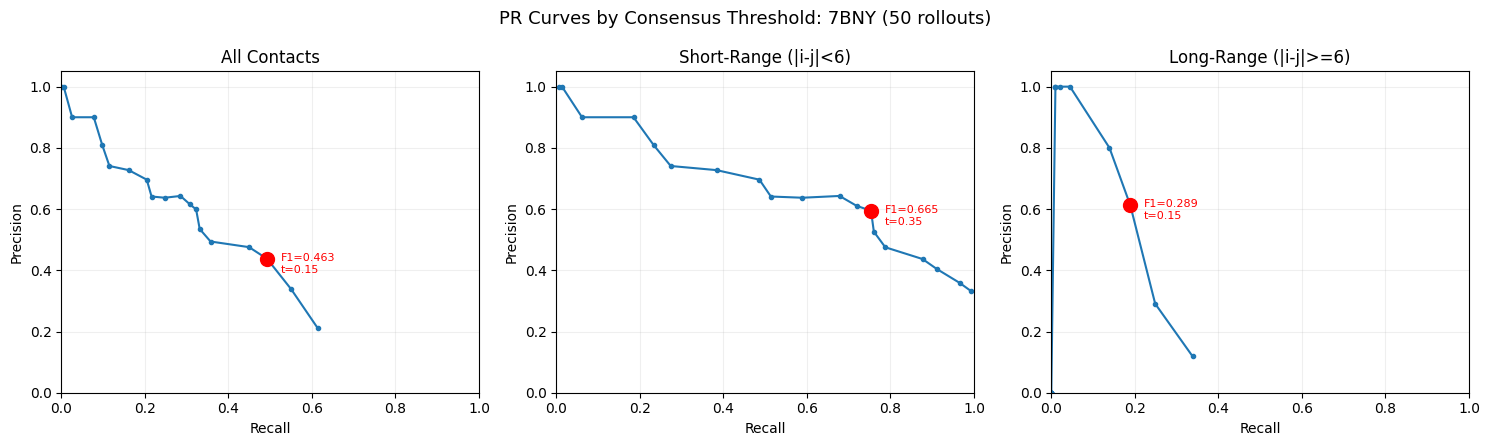

In [10]:
# Strategy 4: Threshold sweep + PR curve
print("=== Strategy 4: Threshold Sweep ===")

# Build frequency matrix from all 50 rollouts
freq_all = np.zeros((seq_len, seq_len), dtype=np.float32)
for contacts, valid, plddt in all_rollouts:
    freq_all += contacts_to_matrix(contacts, seq_len)
freq_all /= N_ROLLOUTS

thresholds = np.arange(0.05, 1.0, 0.05)
pr_data = {"all": [], "short": [], "long": []}

for t in thresholds:
    pairs = set()
    for i in range(seq_len):
        for j in range(i + 1, seq_len):
            if freq_all[i, j] > t:
                pairs.add((i + 1, j + 1))
    m = eval_pairs(pairs, gt_pair_set)
    for scope in ["all", "short", "long"]:
        pr_data[scope].append((m[scope]["rec"], m[scope]["prec"], m[scope]["f1"], t))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, scope, title in zip(axes, ["all", "short", "long"],
                             ["All Contacts", f"Short-Range (|i-j|<{SEP_THRESHOLD})",
                              f"Long-Range (|i-j|>={SEP_THRESHOLD})"]):
    recalls = [r for r, p, f, t in pr_data[scope]]
    precs = [p for r, p, f, t in pr_data[scope]]
    f1s = [f for r, p, f, t in pr_data[scope]]
    ts = [t for r, p, f, t in pr_data[scope]]
    ax.plot(recalls, precs, "o-", markersize=3)
    # Annotate best F1
    best_i = np.argmax(f1s)
    ax.scatter([recalls[best_i]], [precs[best_i]], s=100, color="red", zorder=5)
    ax.annotate(f"F1={f1s[best_i]:.3f}\nt={ts[best_i]:.2f}",
                (recalls[best_i], precs[best_i]), textcoords="offset points",
                xytext=(10, -10), fontsize=8, color="red")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.2)

fig.suptitle(f"PR Curves by Consensus Threshold: {PDB_ID} ({N_ROLLOUTS} rollouts)", fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Strategy 5: Correction-prompted iterative refinement
print("=== Strategy 5: Correction-Prompted Refinement ===")

# Take the best rollout and try to improve it by prompting corrections
best_contacts = all_rollouts[sorted_indices[0]][0]
best_plddt = all_rollouts[sorted_indices[0]][2]

# Build prompt with best rollout's contacts, then append <correction> to invite fixes
contact_toks = []
for is_corr, p1, p2, a1, a2, bin_tok in best_contacts:
    corr = "<correction>" if is_corr else "<non-correction>"
    contact_toks.extend([corr, f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>", f"<{bin_tok}>"])

# Append <correction> to prompt the model to emit a correction
correction_prompt = base_prompt + " " + " ".join(contact_toks) + " <correction>"

# Generate continuation (the model should complete the correction contact)
inputs = tokenizer(correction_prompt, return_tensors="pt", truncation=True, max_length=8192)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

# Generate multiple corrections
n_correction_attempts = 10
correction_results = []
for attempt in range(n_correction_attempts):
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=500, do_sample=True,
            temperature=1.0, top_k=0,
            pad_token_id=tokenizer.pad_token_id, eos_token_id=end_token_id)
    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    new_contacts, valid, plddt = parse_generated_contacts(gen_text.split())
    correction_results.append((new_contacts, valid, plddt))

print(f"Correction attempts: {n_correction_attempts}")
for i, (contacts, valid, plddt) in enumerate(correction_results):
    n_corr = sum(1 for c in contacts if c[0])
    n_new = sum(1 for c in contacts if not c[0])
    print(f"  Attempt {i}: {len(contacts)} contacts ({n_corr} corrections, {n_new} non-corrections), valid={valid}")

# Apply corrections to best rollout: for each correction, update the bin for that pair
# Use the attempt with most corrections
best_attempt = max(range(len(correction_results)),
                   key=lambda i: sum(1 for c in correction_results[i][0] if c[0]))
corr_contacts = correction_results[best_attempt][0]
print(f"\nUsing attempt {best_attempt} with {sum(1 for c in corr_contacts if c[0])} corrections")

# Merge: start with best rollout, apply corrections
refined = {(c[1], c[2]): c for c in best_contacts}  # keyed by pair
for c in corr_contacts:
    refined[(c[1], c[2])] = c  # overwrite with correction
refined_contacts = list(refined.values())

# Evaluate
refined_pairs = contacts_to_pair_set(refined_contacts)
original_pairs = contacts_to_pair_set(best_contacts)
print("\nBefore correction:")
print_eval("Original", eval_pairs(original_pairs, gt_pair_set))
print("\nAfter correction:")
print_eval("Refined", eval_pairs(refined_pairs, gt_pair_set))

=== Strategy 5: Correction-Prompted Refinement ===


Correction attempts: 10
  Attempt 0: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 1: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 2: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 3: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 4: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 5: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 6: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 7: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 8: 0 contacts (0 corrections, 0 non-corrections), valid=False
  Attempt 9: 0 contacts (0 corrections, 0 non-corrections), valid=False

Using attempt 0 with 0 corrections

Before correction:
  Original [  all]: P=35.4% R=30.3% F1=0.326 (105/297 correct, 347 GT)
  Original [short]: P=40.8% R=69.9% F1=0.515 (102/250 correct, 146 GT)
  Original [ long]: P=6.4% R=1.5% F1=0.024 (3/47 correct, 

SUMMARY: 7BNY (132 residues, 347 GT pairs)
  Greedy [  all]: P=80.8% R=6.1% F1=0.113 (21/26 correct, 347 GT)
  Greedy [short]: P=81.8% R=6.2% F1=0.115 (9/11 correct, 146 GT)
  Greedy [ long]: P=80.0% R=6.0% F1=0.111 (12/15 correct, 201 GT)

  Consensus N=10 [  all]: P=66.9% R=22.8% F1=0.340 (79/118 correct, 347 GT)
  Consensus N=10 [short]: P=66.4% R=52.7% F1=0.588 (77/116 correct, 146 GT)
  Consensus N=10 [ long]: P=100.0% R=1.0% F1=0.020 (2/2 correct, 201 GT)

  Consensus N=50 [  all]: P=63.7% R=24.8% F1=0.357 (86/135 correct, 347 GT)
  Consensus N=50 [short]: P=63.7% R=58.9% F1=0.612 (86/135 correct, 146 GT)
  Consensus N=50 [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  PPL-weighted [  all]: P=64.3% R=26.5% F1=0.376 (92/143 correct, 347 GT)
  PPL-weighted [short]: P=64.3% R=63.0% F1=0.637 (92/143 correct, 146 GT)
  PPL-weighted [ long]: P=0.0% R=0.0% F1=0.000 (0/0 correct, 201 GT)

  Best-of-50 [  all]: P=35.4% R=30.3% F1=0.326 (105/297 correct, 347 GT)
  Best-of-50 [shor

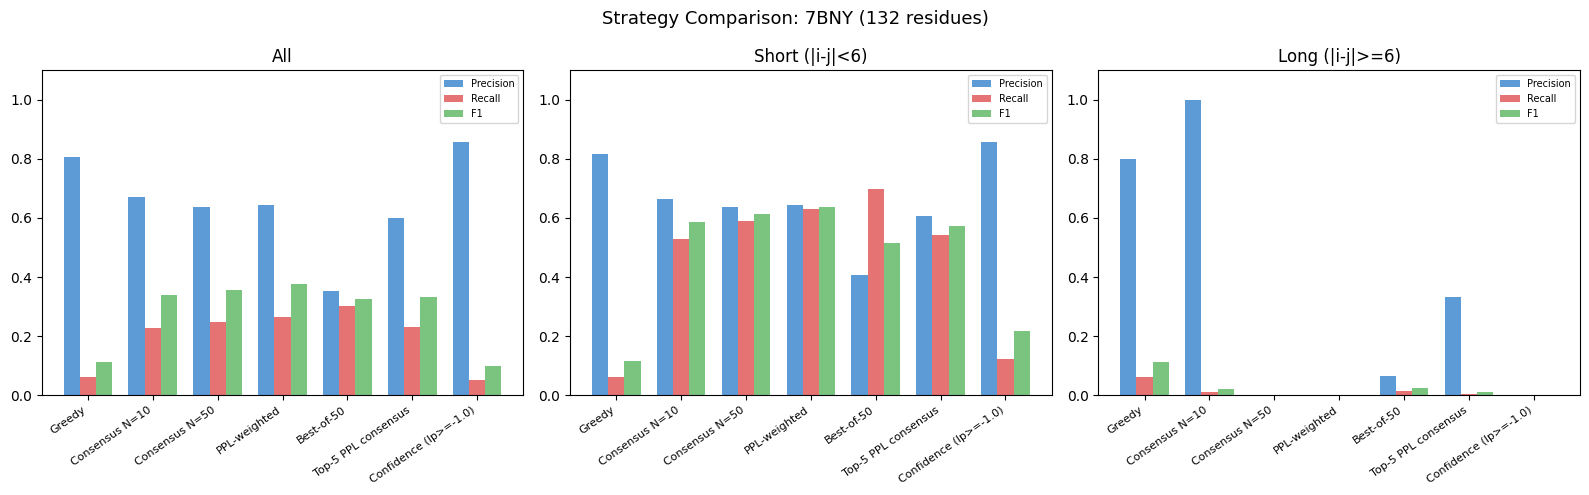

In [12]:
# Summary comparison
print("=" * 80)
print(f"SUMMARY: {PDB_ID} ({seq_len} residues, {len(gt_pair_set)} GT pairs)")
print("=" * 80)

summary_rows = []

# Greedy
greedy_pairs = contacts_to_pair_set(greedy_contacts)
m = eval_pairs(greedy_pairs, gt_pair_set)
summary_rows.append(("Greedy", m))
print_eval("Greedy", m)
print()

# Baseline consensus
for n in [10, 50]:
    pairs, _ = consensus_pairs(all_rollouts, n)
    m = eval_pairs(pairs, gt_pair_set)
    summary_rows.append((f"Consensus N={n}", m))
    print_eval(f"Consensus N={n}", m)
    print()

# PPL-weighted
pairs, _ = weighted_consensus_pairs(all_rollouts, rollout_ppls, N_ROLLOUTS, sharpness=1.0)
m = eval_pairs(pairs, gt_pair_set)
summary_rows.append(("PPL-weighted", m))
print_eval("PPL-weighted", m)
print()

# Best-of-N
m = eval_pairs(best_pairs, gt_pair_set)
summary_rows.append(("Best-of-50", m))
print_eval("Best-of-50", m)
print()

# Top-5 consensus
top_5 = sorted_indices[:5]
top5_rollouts = [(all_rollouts[i][0], all_rollouts[i][1], all_rollouts[i][2]) for i in top_5]
top5_ppls = [rollout_ppls[i] for i in top_5]
pairs, _ = weighted_consensus_pairs(top5_rollouts, top5_ppls, 5, sharpness=1.0)
m = eval_pairs(pairs, gt_pair_set)
summary_rows.append(("Top-5 PPL consensus", m))
print_eval("Top-5 PPL consensus", m)
print()

# Confidence filtered
freq = np.zeros((seq_len, seq_len), dtype=np.float32)
for paired in rollout_contact_logprobs:
    for contact, lp in paired:
        if contact[5] != "bin_lt4" or lp < -1.0:
            continue
        p1, p2 = contact[1], contact[2]
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            freq[p1 - 1, p2 - 1] += 1
            freq[p2 - 1, p1 - 1] += 1
freq /= N_ROLLOUTS
conf_pairs = set()
for i in range(seq_len):
    for j in range(i + 1, seq_len):
        if freq[i, j] > 0.5:
            conf_pairs.add((i + 1, j + 1))
m = eval_pairs(conf_pairs, gt_pair_set)
summary_rows.append(("Confidence (lp>=-1.0)", m))
print_eval("Confidence (lp>=-1.0)", m)
print()

# Summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [r[0] for r in summary_rows]
x = np.arange(len(labels))

for ax, scope, title in zip(axes, ["all", "short", "long"],
                             ["All", f"Short (|i-j|<{SEP_THRESHOLD})",
                              f"Long (|i-j|>={SEP_THRESHOLD})"]):
    precs = [r[1][scope]["prec"] for r in summary_rows]
    recs = [r[1][scope]["rec"] for r in summary_rows]
    f1s = [r[1][scope]["f1"] for r in summary_rows]
    w = 0.25
    ax.bar(x - w, precs, w, label="Precision", color="#5C9BD5")
    ax.bar(x, recs, w, label="Recall", color="#E57373")
    ax.bar(x + w, f1s, w, label="F1", color="#7BC47F")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=7)

fig.suptitle(f"Strategy Comparison: {PDB_ID} ({seq_len} residues)", fontsize=13)
plt.tight_layout()
plt.show()